# Malaria Diagnosis: Data Preparation

This notebook follows the exact same structure as the diabetes project, so
if you worked through that one, this will feel very familiar. The goal is
the same too: end up with a clean, feature-engineered, scaled dataset saved
to disk, ready for `02_malaria_ann_training.ipynb`.

**Important note on the data:** unlike the Pima Diabetes dataset, there is
no single standard, reliable tabular malaria dataset that beginners can
just download. Real malaria datasets are almost always microscope images
of blood cells (a computer vision problem, not an ANN-on-a-table problem).

So, for this teaching example, we **generate a synthetic clinical dataset**
ourselves: patient symptoms (fever, chills, headache, and so on) with a
malaria positive/negative label, built using realistic clinical patterns
(malaria patients typically run high fevers, report chills, headaches,
fatigue, and so on, far more often than uninfected patients). This keeps
the notebook fully reproducible for every student, with no broken links,
while still practicing every real skill: cleaning, feature engineering,
splitting, scaling.

**What this notebook covers:**
1. Generate the synthetic patient dataset
2. Load and inspect it
3. Explore it visually (EDA)
4. Fix missing values
5. Engineer a few extra features
6. Split into train / validation / test
7. Scale the features and save everything to disk (CSV, JSON, and PKL)


## Step 1: Import libraries

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Step 2: Generate the synthetic patient dataset

We simulate 800 patients. Each patient either has malaria or doesn't, and
their symptoms are generated to reflect realistic clinical patterns:
malaria patients tend to run a higher fever, report chills far more often,
have more severe headaches, and feel more fatigued, but with plenty of
random variation, since real patients never fit a pattern perfectly.

In [2]:
N_PATIENTS = 800

# 40% of our simulated patients are malaria-positive
malaria_positive = (np.random.rand(N_PATIENTS) < 0.40).astype(int)

def simulate(mean_pos, std_pos, mean_neg, std_neg, low=None, high=None):
    """Draw a numeric symptom, using different mean/spread for each class."""
    values = np.where(
        malaria_positive == 1,
        np.random.normal(mean_pos, std_pos, N_PATIENTS),
        np.random.normal(mean_neg, std_neg, N_PATIENTS),
    )
    if low is not None or high is not None:
        values = np.clip(values, low, high)
    return values

def simulate_binary(p_pos, p_neg):
    """Draw a yes/no symptom, with a different probability per class."""
    p = np.where(malaria_positive == 1, p_pos, p_neg)
    return (np.random.rand(N_PATIENTS) < p).astype(int)

df = pd.DataFrame({
    'Age': np.clip(np.random.normal(30, 15, N_PATIENTS), 1, 85).round(0),
    'Fever_Temp': simulate(38.6, 0.9, 37.0, 0.6, low=35.5, high=41.5).round(1),
    'Chills': simulate_binary(0.85, 0.15),
    'Headache_Severity': simulate(7.0, 2.0, 2.8, 1.8, low=0, high=10).round(1),
    'Vomiting': simulate_binary(0.40, 0.10),
    'Diarrhea': simulate_binary(0.30, 0.08),
    'Muscle_Pain': simulate(6.0, 2.0, 2.0, 1.5, low=0, high=10).round(1),
    'Fatigue_Level': simulate(7.0, 2.0, 3.0, 2.0, low=0, high=10).round(1),
    'Sweating': simulate_binary(0.70, 0.20),
    'Nausea': simulate_binary(0.50, 0.15),
    'Malaria_Positive': malaria_positive,
})

# Simulate a realistic data-collection problem: some fever readings were
# never taken (recorded as 0), the same "impossible zero" idea as the
# diabetes dataset.
missing_mask = np.random.rand(N_PATIENTS) < 0.05
df.loc[missing_mask, 'Fever_Temp'] = 0.0

df.to_csv('malaria_raw.csv', index=False)
print(f"Generated {len(df)} synthetic patients")
df.head()


Generated 800 synthetic patients


,Age,Fever_Temp,Chills,Headache_Severity,Vomiting,Diarrhea,Muscle_Pain,Fatigue_Level,Sweating,Nausea,Malaria_Positive
0,18.0,39.1,1,6.3,1,0,3.6,9.2,1,1,1
1,37.0,36.6,0,6.1,0,0,0.5,4.4,0,0,0
2,58.0,37.4,0,4.3,0,0,1.3,1.2,0,0,0
3,50.0,36.9,0,4.9,0,0,0.9,1.4,0,0,0
4,54.0,37.7,1,9.4,1,0,4.5,3.5,1,1,1


## Step 3: Load and inspect

From this point on the notebook works exactly like a real dataset, this
is exactly what you'd do the moment any CSV lands in your hands.

In [3]:
df = pd.read_csv('malaria_raw.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.describe().round(2)


Shape:         (800, 11)
Duplicates:    0
Missing (NaN): 0


,Age,Fever_Temp,Chills,Headache_Severity,Vomiting,Diarrhea,Muscle_Pain,Fatigue_Level,Sweating,Nausea,Malaria_Positive
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,31.22,35.69,0.44,4.52,0.24,0.19,3.64,4.60,0.41,0.31,0.42
std,14.64,8.47,0.50,2.62,0.43,0.40,2.54,2.65,0.49,0.46,0.49
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,21.00,36.80,0.00,2.58,0.00,0.00,1.60,2.60,0.00,0.00,0.00
50%,31.00,37.40,0.00,4.20,0.00,0.00,3.30,4.40,0.00,0.00,0.00
75%,41.00,38.30,1.00,6.40,0.00,0.00,5.40,6.50,1.00,1.00,1.00
max,69.00,41.50,1.00,10.00,1.00,1.00,10.00,10.00,1.00,1.00,1.00


### Class balance

Negative: 467  (58.4%)
Positive: 333  (41.6%)


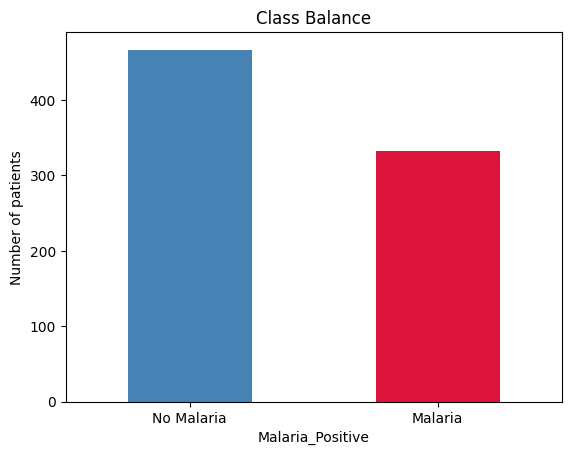

In [4]:
counts = df['Malaria_Positive'].value_counts()

print(f"Negative: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"Positive: {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['No Malaria', 'Malaria'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()


## Step 4: Explore the data visually (EDA)

Same two questions as always: how does each feature differ between the
two classes, and how do features correlate with each other?

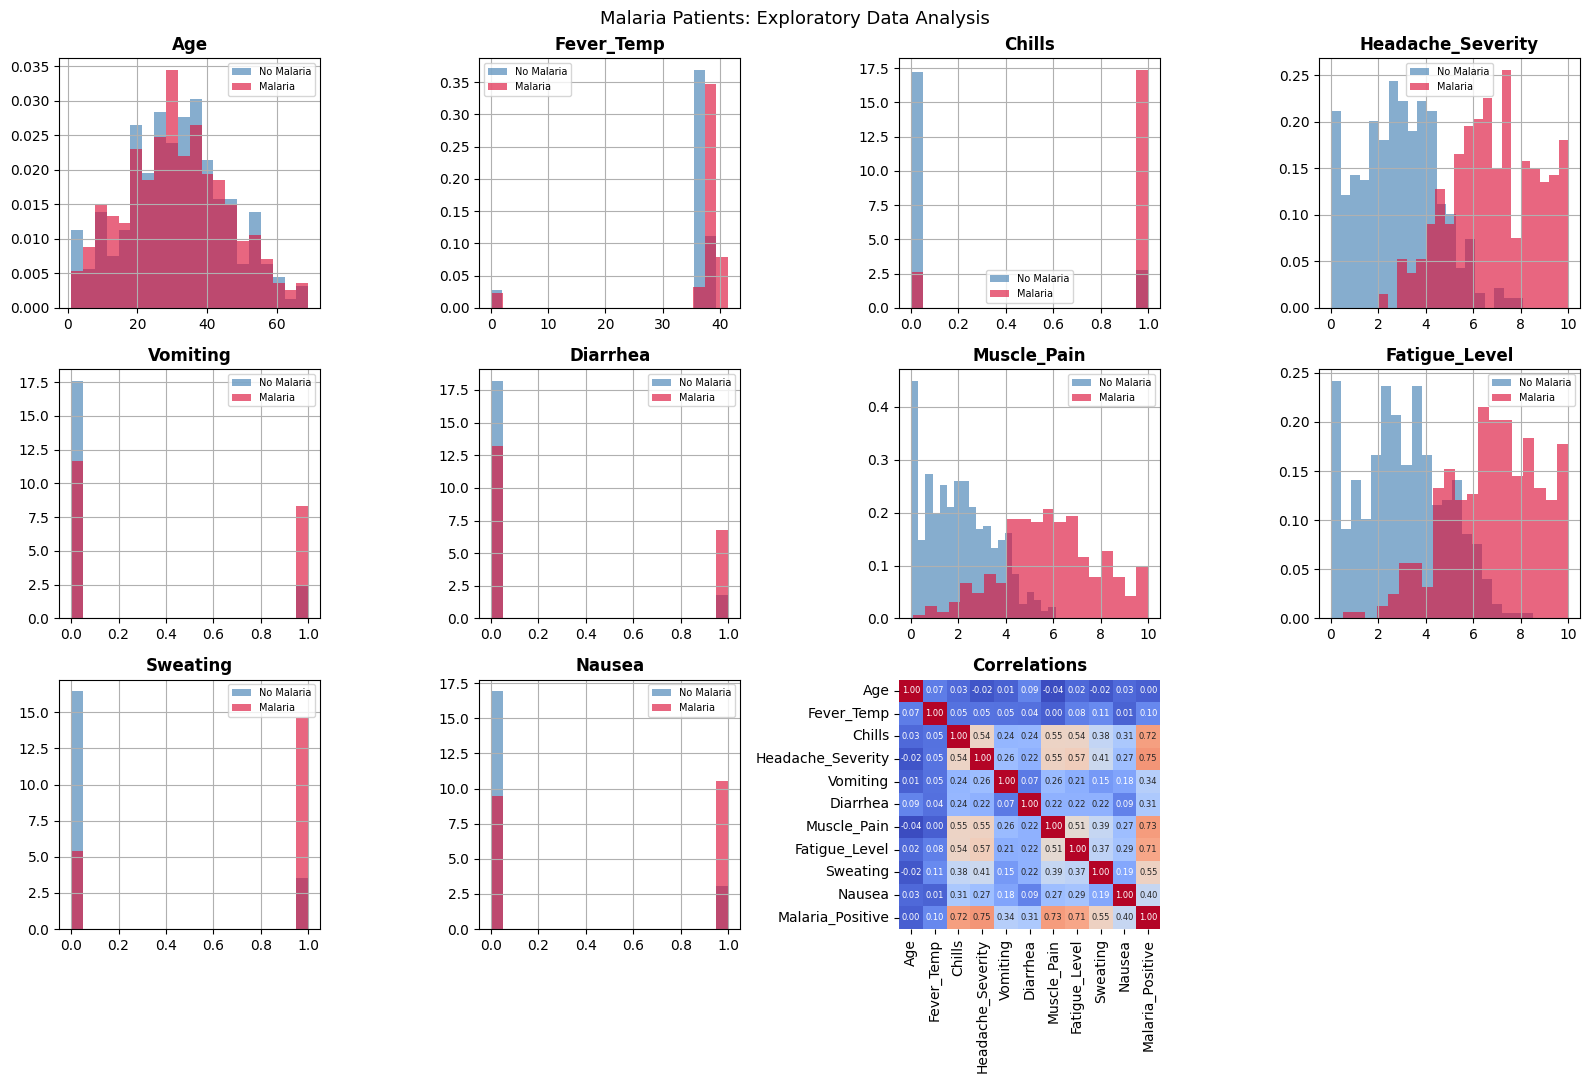

In [5]:
FEATURES = ['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting',
            'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea']

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    df[df['Malaria_Positive'] == 0][col].hist(ax=axes[i], bins=20, alpha=0.65,
                                                color='steelblue', label='No Malaria', density=True)
    df[df['Malaria_Positive'] == 1][col].hist(ax=axes[i], bins=20, alpha=0.65,
                                                color='crimson', label='Malaria', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[10], cbar=False, annot_kws={'size': 6})
axes[10].set_title('Correlations', fontweight='bold')
axes[11].axis('off')

plt.suptitle('Malaria Patients: Exploratory Data Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('malaria_eda.png', dpi=150, bbox_inches='tight')
plt.show()


Notice how clearly `Fever_Temp`, `Chills`, and `Headache_Severity`
separate the two classes, this mirrors real clinical knowledge: these are
classic hallmark symptoms of malaria.

## Step 5: Fix missing values

Just like `Glucose = 0` in the diabetes dataset, `Fever_Temp = 0` here
means "never measured," not "patient has a temperature of 0 degrees." We
fix it the same way: replace with the median, calculated separately per
class so we don't blur the signal between the two groups.

In [6]:
n_missing = (df['Fever_Temp'] == 0).sum()
print(f"Fever_Temp readings missing: {n_missing} ({n_missing / len(df):.1%})")

df_clean = df.copy()
train_medians = {}

for label in [0, 1]:
    real_values = df_clean.loc[(df_clean['Malaria_Positive'] == label) & (df_clean['Fever_Temp'] > 0), 'Fever_Temp']
    median = real_values.median()
    mask = (df_clean['Fever_Temp'] == 0) & (df_clean['Malaria_Positive'] == label)
    df_clean.loc[mask, 'Fever_Temp'] = median
    print(f"Fever_Temp (class={label}): replaced {mask.sum()} zeros with {median:.1f}")

train_medians['Fever_Temp'] = float(df_clean.loc[df_clean['Fever_Temp'] > 0, 'Fever_Temp'].median())
print(f"\nZeros remaining: {(df_clean['Fever_Temp'] == 0).sum()}")


Fever_Temp readings missing: 42 (5.2%)
Fever_Temp (class=0): replaced 26 zeros with 37.0
Fever_Temp (class=1): replaced 16 zeros with 38.5

Zeros remaining: 0


## Step 6: Feature engineering

Same idea as the diabetes notebook: hand the network a few features that
clinicians already know matter, so it doesn't have to rediscover them from
only 800 rows.

- **High_Fever**: 38.0C or above is a widely used clinical fever threshold
- **Fever_x_Chills**: fever combined with chills is a classic malaria
  presentation together, more informative than either alone
- **Severe_Headache**: headache severity 7+/10
- **Symptom_Count**: how many of the yes/no symptoms this patient has,
  more symptoms together is a stronger signal than any single one
- **Vulnerable_Age**: children under 5 and adults over 60 are known
  higher-risk groups for severe malaria

In [7]:
df_feat = df_clean.copy()

df_feat['High_Fever'] = (df_feat['Fever_Temp'] >= 38.0).astype(float)
df_feat['Fever_x_Chills'] = df_feat['Fever_Temp'] * df_feat['Chills']
df_feat['Severe_Headache'] = (df_feat['Headache_Severity'] >= 7).astype(float)
df_feat['Symptom_Count'] = (df_feat['Chills'] + df_feat['Vomiting'] + df_feat['Diarrhea']
                             + df_feat['Sweating'] + df_feat['Nausea'])
df_feat['Vulnerable_Age'] = ((df_feat['Age'] < 5) | (df_feat['Age'] > 60)).astype(float)

FEATURE_COLS = [c for c in df_feat.columns if c != 'Malaria_Positive']
print(f"Total features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

df_feat.head()


Total features: 15
['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea', 'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count', 'Vulnerable_Age']


,Age,Fever_Temp,Chills,Headache_Severity,Vomiting,Diarrhea,Muscle_Pain,Fatigue_Level,Sweating,Nausea,Malaria_Positive,High_Fever,Fever_x_Chills,Severe_Headache,Symptom_Count,Vulnerable_Age
0,18.0,39.1,1,6.3,1,0,3.6,9.2,1,1,1,1.0,39.1,0.0,4,0.0
1,37.0,36.6,0,6.1,0,0,0.5,4.4,0,0,0,0.0,0.0,0.0,0,0.0
2,58.0,37.4,0,4.3,0,0,1.3,1.2,0,0,0,0.0,0.0,0.0,0,0.0
3,50.0,36.9,0,4.9,0,0,0.9,1.4,0,0,0,0.0,0.0,0.0,0,0.0
4,54.0,37.7,1,9.4,1,0,4.5,3.5,1,1,1,0.0,37.7,1.0,4,0.0


## Step 7: Split into train / validation / test

Same ratios as the diabetes notebook: about 70% train, 15% validation,
15% test, stratified so all three sets keep the same malaria/no-malaria
proportion.

In [8]:
X = df_feat[FEATURE_COLS].values.astype(np.float32)
y = df_feat['Malaria_Positive'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")


Train:  560 rows  (41.6% positive)
Val:    120 rows  (41.7% positive)
Test:   120 rows  (41.7% positive)


## Step 8: Scale the features

Fit the scaler on the training data only, then apply it to validation
and test.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Example, first row before and after scaling:")
print("Before:", X_train[0][:5])
print("After: ", X_train_scaled[0][:5].round(2))


Example, first row before and after scaling:
Before: [30.  39.2  1.   5.8  0. ]
After:  [-0.1   1.52  1.15  0.48 -0.57]


## Step 9: Save everything, as CSV, JSON, and PKL

Same three-format approach as the diabetes notebook:

- **CSV**: the scaled train / val / test tables, what the training
  notebook loads directly to train the ANN
- **JSON**: the same three sets, human-readable, and separately, small
  metadata (feature names, imputation median, scaler numbers)
- **PKL**: one convenience bundle with everything, in case you want it
  all in a single load

In [10]:
train_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
train_df['Malaria_Positive'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS)
val_df['Malaria_Positive'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
test_df['Malaria_Positive'] = y_test

train_df.to_csv('malaria_train.csv', index=False)
val_df.to_csv('malaria_val.csv', index=False)
test_df.to_csv('malaria_test.csv', index=False)
print("Saved malaria_train.csv, malaria_val.csv, malaria_test.csv")


Saved malaria_train.csv, malaria_val.csv, malaria_test.csv


In [11]:
train_df.to_json('malaria_train.json', orient='records', indent=2)
val_df.to_json('malaria_val.json', orient='records', indent=2)
test_df.to_json('malaria_test.json', orient='records', indent=2)
print("Saved malaria_train.json, malaria_val.json, malaria_test.json")


Saved malaria_train.json, malaria_val.json, malaria_test.json


In [12]:
import json

metadata = {
    'feature_cols': FEATURE_COLS,
    'train_medians': train_medians,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}

with open('malaria_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Saved malaria_metadata.json")

prepared_extras = {
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'train_medians': train_medians,
}

with open('malaria_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_extras, f)
print("Saved malaria_prepared.pkl")


Saved malaria_metadata.json
Saved malaria_prepared.pkl


### Done

We now have a clean, feature-engineered, scaled malaria dataset saved as
CSV, JSON, and PKL. Open **`02_malaria_ann_training.ipynb`** next to build
and train the neural network, using the CSV files directly, exactly like
the diabetes project.